In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [ ]:
eta = 0.05
iteration = 20

def _sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

def fit(X, y):
    # set the seed
    # initialize the W
    rgn = np.random.RandomState(seed=42)
    w_ = rgn.normal(loc=0.0, scale=0.5, size=1 + X.shape[1])

    loss_ = []
    for _ in range(iteration):
        # 1) calculate the net input
        net_input = np.dot(X, w_[1:]) + w_[0]

        # 2) apply the sigmoid
        y_pred = _sigmoid(net_input)

        # 3) calcualte the error
        errors = y - y_pred

        # 4) calculate the gradient
        gradient = X.T.dot(errors)

        # 5) update the w_ 
        w_[1:] += eta * gradient
        w_[0] += eta * errors.sum()

        # 6) calcualte the loss
        y_pred = np.clip(y_pred, 1e-15 , 1-1e-15) # if y_pred = 0, then np.log(y_pred) would show error
        loss = -(y.dot(np.log(y_pred)) + (1 - y).dot(np.log(1 - y_pred))) / X.shape[0]

        loss_.append(loss)

    return loss_, w_

def predict(X, w):
    net_input = np.dot(X, w[1:]) + w[0]
    y_pred = _sigmoid(net_input)
    y = np.where(y_pred >= 0.5, 1, 0)
    return y

In [12]:
# load the iris datasets
X, y = datasets.load_iris(return_X_y=True)

X = StandardScaler().fit_transform(X)

# only pick the two classes
X = X[y != 2]
y = y[y != 2]

# check the data sample size
print(f'Dataset size: {X.shape}')


# apply the model
cost, w = fit(X, y)

# apply the forecast
y_pred = predict(X, w)

# calculate the accuracy
accuracy = accuracy_score(y, y_pred)
print(f'Accuracy: {accuracy:.3f}')

Dataset size: (100, 4)
Accuracy: 1.000


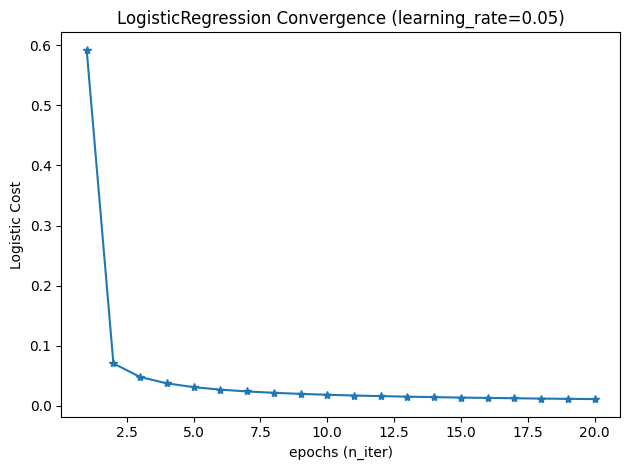

In [17]:
plt.plot(range(1, iteration+1), cost, marker='*')
plt.xlabel('epochs (n_iter)')
plt.ylabel('Logistic Cost')
plt.title('LogisticRegression Convergence (learning_rate=0.05)')
plt.tight_layout()
plt.show()